# Exploratory Data Analysis

## Mutual Fund Performance Analytics

Prepared by:
Besi Karthik

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW_FOLDER = Path("data/raw")

In [2]:
fund_master = pd.read_csv(RAW_FOLDER / "01_fund_master.csv")
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [3]:
fund_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [4]:
fund_master.describe()

,amfi_code,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40.000000,40.000000,40.0,40.000000
mean,120247.000000,1.237000,0.812500,500.0,1277.500000
std,14534.998667,0.386584,0.387091,0.0,1082.847031
min,100016.000000,0.550000,0.000000,500.0,100.000000
25%,118632.750000,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,1.540000,1.000000,500.0,1000.000000
max,149324.000000,1.640000,1.000000,500.0,5000.000000


In [5]:
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

## Fund House Distribution

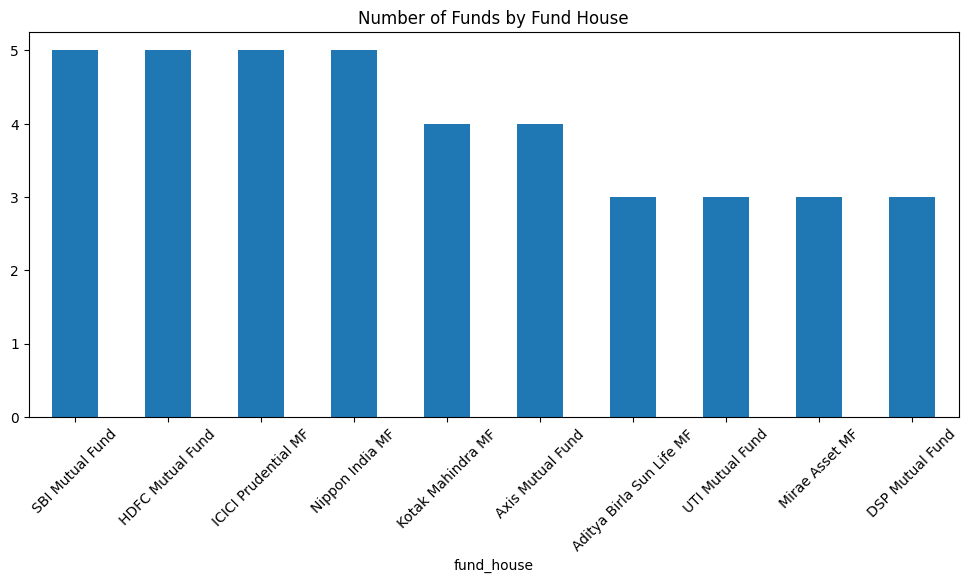

In [6]:
fund_master["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(12,5),
    title="Number of Funds by Fund House"
)

plt.xticks(rotation=45)
plt.show()

## Category Distribution

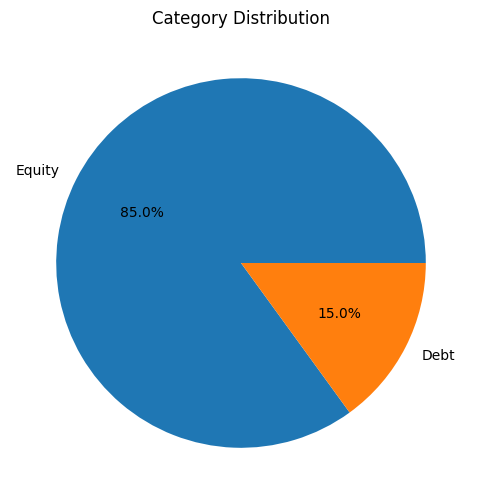

In [7]:
fund_master["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Category Distribution")
plt.show()

In [8]:
aum = pd.read_csv(RAW_FOLDER / "03_aum_by_fund_house.csv")
sip = pd.read_csv(RAW_FOLDER / "04_monthly_sip_inflows.csv")
transactions = pd.read_csv(RAW_FOLDER / "08_investor_transactions.csv")

## Industry AUM Trend

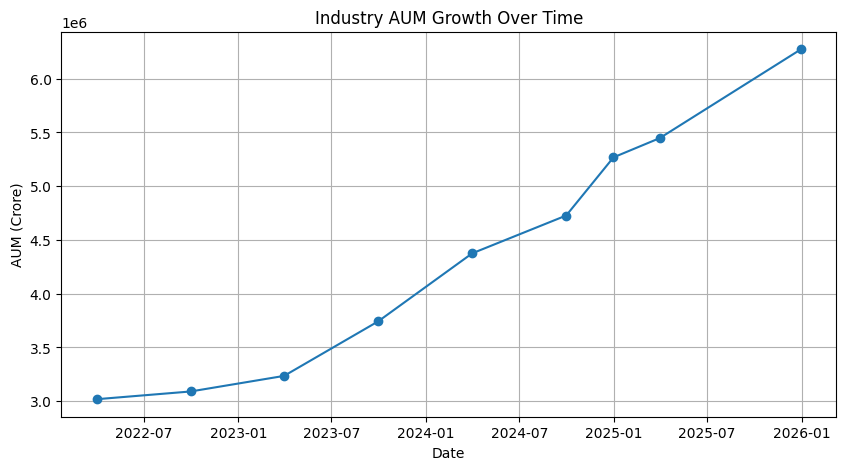

In [9]:
aum["date"] = pd.to_datetime(aum["date"])

industry_aum = aum.groupby("date")["aum_crore"].sum()

plt.figure(figsize=(10,5))
plt.plot(industry_aum.index, industry_aum.values, marker="o")
plt.title("Industry AUM Growth Over Time")
plt.xlabel("Date")
plt.ylabel("AUM (Crore)")
plt.grid(True)
plt.show()

## Top Fund Houses by AUM

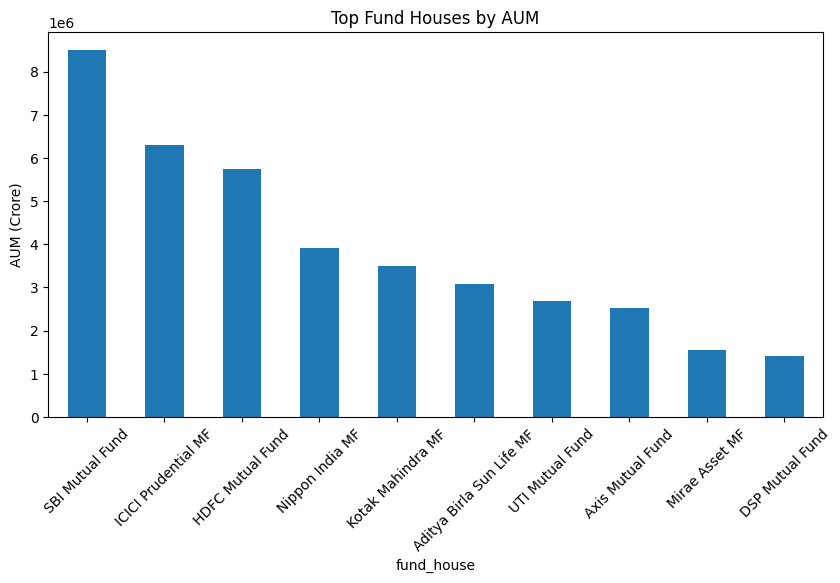

In [10]:
top_funds = aum.groupby("fund_house")["aum_crore"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_funds.plot(kind="bar")
plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)
plt.show()

## Monthly SIP Inflows

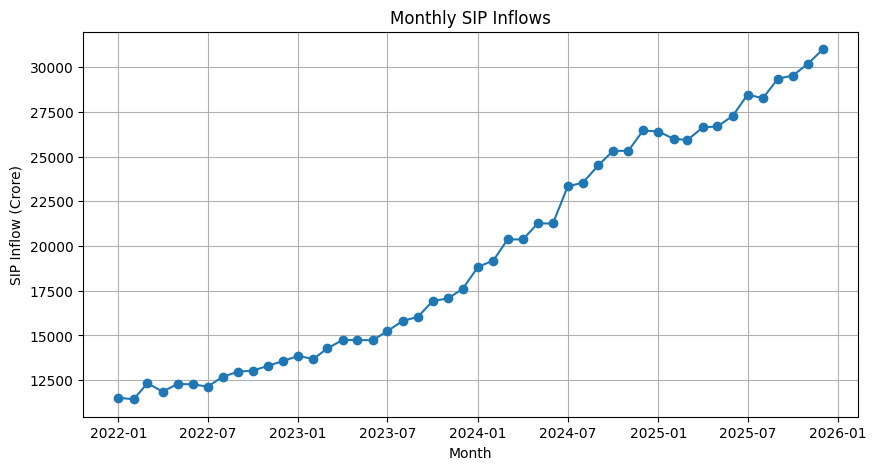

In [11]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(10,5))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")
plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.grid(True)
plt.show()

## Transaction Type Distribution

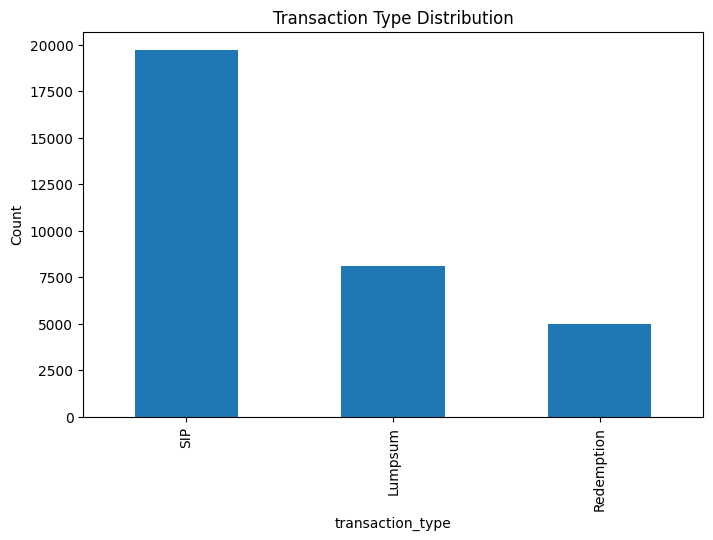

In [12]:
transactions["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")
plt.ylabel("Count")
plt.show()